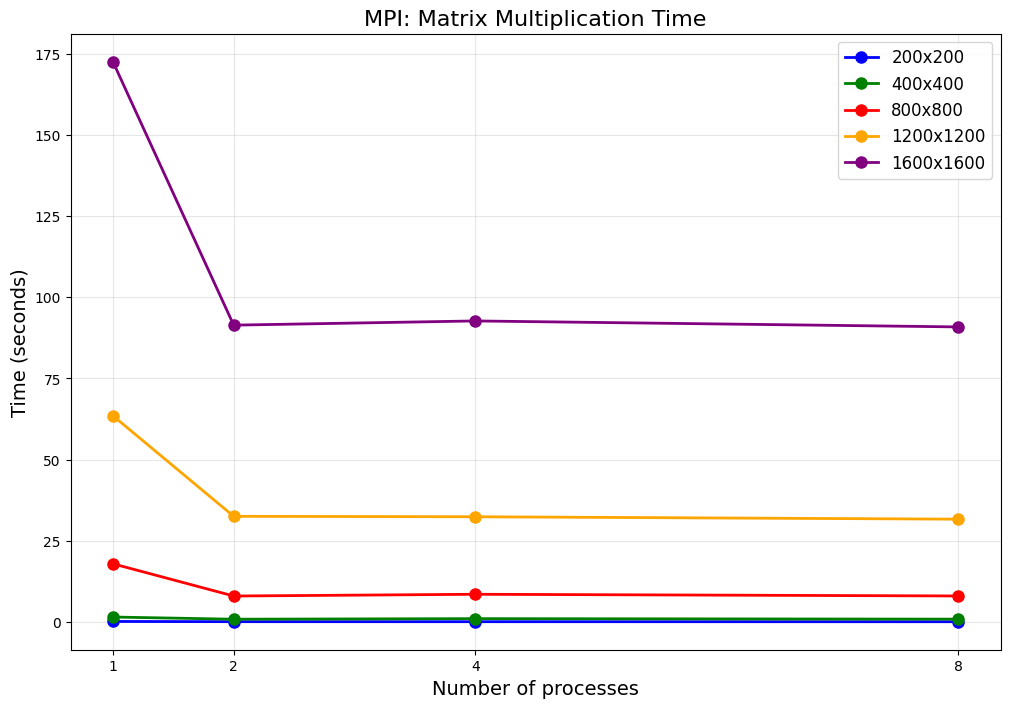

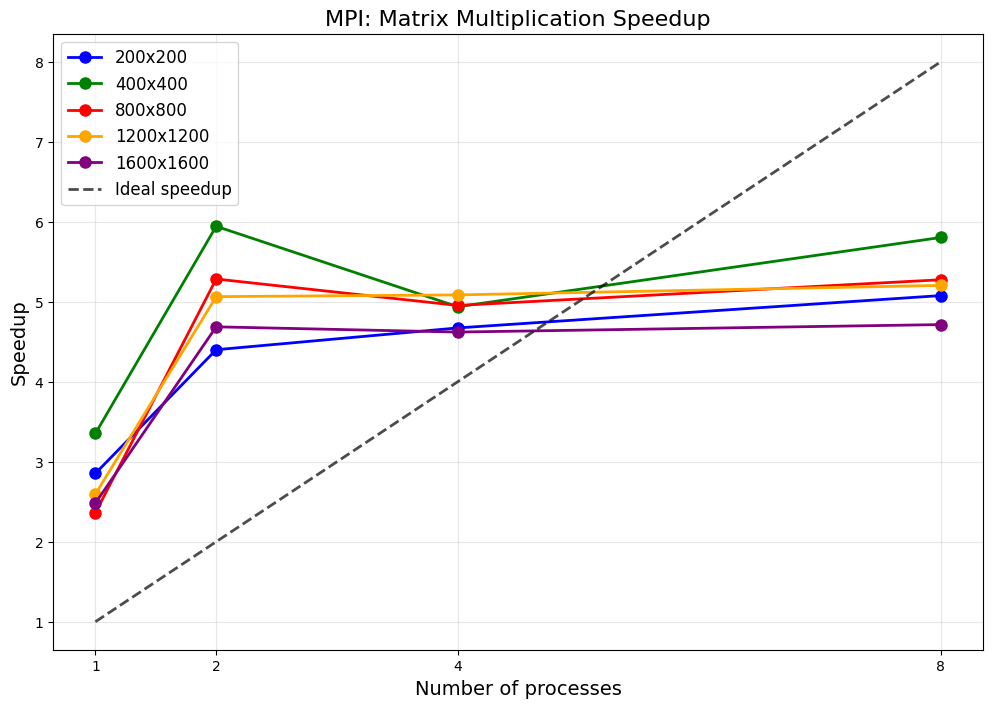

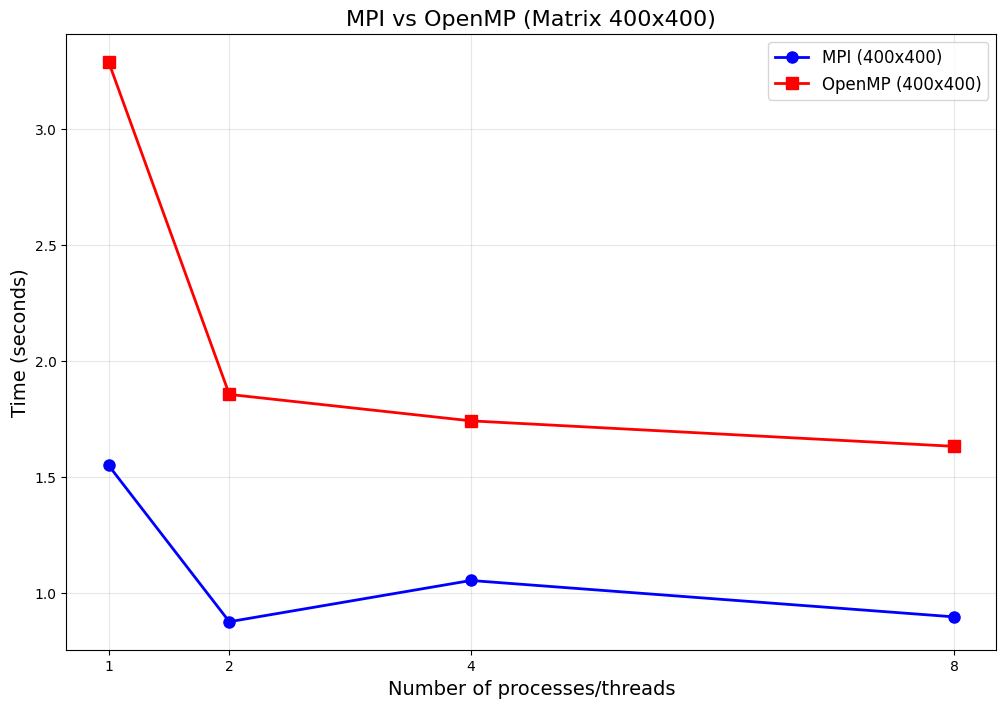

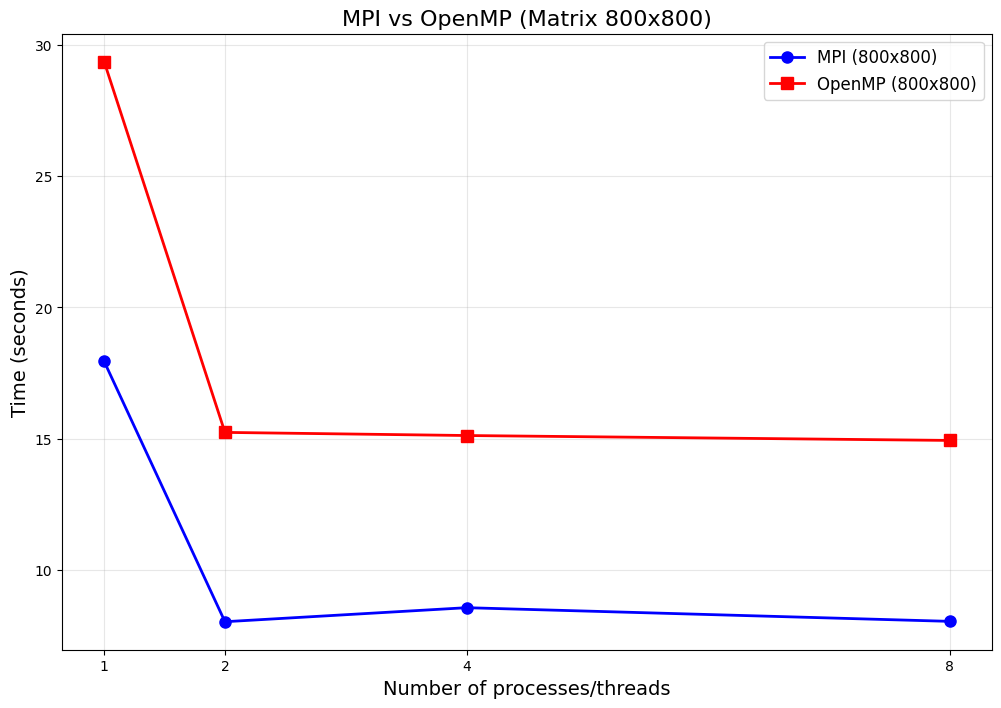


MPI RESULTS

Execution time (seconds):
Size   1 proc   2 proc   4 proc   8 proc
--------------------------------------------------
200    0.185    0.120    0.113    0.104   
400    1.549    0.874    1.052    0.895   
800    17.941   8.019    8.554    8.033   
1200   63.523   32.559   32.419   31.679  
1600   172.528  91.420   92.715   90.875  

Speedup:
Size   1 proc   2 proc   4 proc   8 proc
--------------------------------------------------
200    2.85     4.40     4.67     5.08    
400    3.35     5.94     4.94     5.80    
800    2.36     5.28     4.95     5.27    
1200   2.60     5.06     5.09     5.20    
1600   2.48     4.69     4.62     4.71    

Graphs saved:
  - mpi_time_graph.png
  - mpi_speedup_graph.png
  - mpi_vs_omp_400.png
  - mpi_vs_omp_800.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Данные MPI (из ваших экспериментов)
sizes = [200, 400, 800, 1200, 1600]
processes = [1, 2, 4, 8]

# Время выполнения MPI (секунды)
mpi_times = {
    200: [0.185, 0.120, 0.113, 0.104],
    400: [1.549, 0.874, 1.052, 0.895],
    800: [17.941, 8.019, 8.554, 8.033],
    1200: [63.523, 32.559, 32.419, 31.679],
    1600: [172.528, 91.420, 92.715, 90.875]
}

# Данные OpenMP (из предыдущих экспериментов)
omp_times = {
    400: [3.291, 1.855, 1.741, 1.631],
    800: [29.366, 15.236, 15.117, 14.930],
    1200: [120.496, 65.187, 63.680, 62.976],
    1600: [393.286, 175.500, 176.323, 171.829]
}

# Последовательное время (для расчёта ускорения)
seq_times = {
    200: 0.528,
    400: 5.194,
    800: 42.372,
    1200: 164.858,
    1600: 428.409
}

# =============================================
# ГРАФИК 1: Время выполнения MPI
# =============================================
plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'orange', 'purple']

for i, size in enumerate(sizes):
    plt.plot(processes, mpi_times[size], 'o-', color=colors[i],
             label=f'{size}x{size}', linewidth=2, markersize=8)

plt.xlabel('Number of processes', fontsize=14)
plt.ylabel('Time (seconds)', fontsize=14)
plt.title('MPI: Matrix Multiplication Time', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(processes)
plt.savefig('mpi_time_graph.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# ГРАФИК 2: Ускорение MPI
# =============================================
plt.figure(figsize=(12, 8))

for i, size in enumerate(sizes):
    speedups = []
    base_time = seq_times[size]
    for t in range(len(processes)):
        speedup = base_time / mpi_times[size][t]
        speedups.append(speedup)
    plt.plot(processes, speedups, 'o-', color=colors[i],
             label=f'{size}x{size}', linewidth=2, markersize=8)

# Идеальное ускорение
plt.plot(processes, processes, 'k--', label='Ideal speedup', linewidth=2, alpha=0.7)

plt.xlabel('Number of processes', fontsize=14)
plt.ylabel('Speedup', fontsize=14)
plt.title('MPI: Matrix Multiplication Speedup', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(processes)
plt.savefig('mpi_speedup_graph.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# ГРАФИК 3: Сравнение MPI и OpenMP (для 400)
# =============================================
plt.figure(figsize=(12, 8))

plt.plot(processes, mpi_times[400], 'o-', color='blue',
         label='MPI (400x400)', linewidth=2, markersize=8)
plt.plot(processes, omp_times[400], 's-', color='red',
         label='OpenMP (400x400)', linewidth=2, markersize=8)

plt.xlabel('Number of processes/threads', fontsize=14)
plt.ylabel('Time (seconds)', fontsize=14)
plt.title('MPI vs OpenMP (Matrix 400x400)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(processes)
plt.savefig('mpi_vs_omp_400.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# ГРАФИК 4: Сравнение MPI и OpenMP (для 800)
# =============================================
plt.figure(figsize=(12, 8))

plt.plot(processes, mpi_times[800], 'o-', color='blue',
         label='MPI (800x800)', linewidth=2, markersize=8)
plt.plot(processes, omp_times[800], 's-', color='red',
         label='OpenMP (800x800)', linewidth=2, markersize=8)

plt.xlabel('Number of processes/threads', fontsize=14)
plt.ylabel('Time (seconds)', fontsize=14)
plt.title('MPI vs OpenMP (Matrix 800x800)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(processes)
plt.savefig('mpi_vs_omp_800.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# ВЫВОД ТАБЛИЦЫ РЕЗУЛЬТАТОВ
# =============================================
print("\n" + "="*80)
print("MPI RESULTS")
print("="*80)

print("\nExecution time (seconds):")
print("Size   1 proc   2 proc   4 proc   8 proc")
print("-"*50)
for size in sizes:
    row = f"{size:<6}"
    for t in range(len(processes)):
        row += f" {mpi_times[size][t]:<8.3f}"
    print(row)

print("\nSpeedup:")
print("Size   1 proc   2 proc   4 proc   8 proc")
print("-"*50)
for size in sizes:
    row = f"{size:<6}"
    base_time = seq_times[size]
    for t in range(len(processes)):
        speedup = base_time / mpi_times[size][t]
        row += f" {speedup:<8.2f}"
    print(row)

print("\n" + "="*80)
print("Graphs saved:")
print("  - mpi_time_graph.png")
print("  - mpi_speedup_graph.png")
print("  - mpi_vs_omp_400.png")
print("  - mpi_vs_omp_800.png")
print("="*80)